# SMS Spam Detector
## Model Training & Evaluation

**Goal:** Train multiple ML models, compare their performance and select the best one.

## 1. Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pickle

## 2. Loading Processed Dataset

In [4]:
df = pd.read_csv('../data/spam_processed.csv')
print(df.shape)
df.head()

(5169, 6)


,label,message,length,word_count,label_enc,processed
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,29,6,0,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,49,11,0,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0,nah dont think goe usf live around though


## 3. Train-Test Split

In [5]:
X = df['processed']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                     test_size=0.2, 
                                                     random_state=42,
                                                     stratify=y)

print(f"Training size: {X_train.shape[0]}")
print(f"Testing size: {X_test.shape[0]}")

Training size: 4135
Testing size: 1034


## 4. Building Models with Pipelines

We use Scikit-learn Pipelines to chain vectorization and model training together.
This prevents data leakage and makes the code clean and deployable.

In [6]:
models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('model', MultinomialNB())
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('model', LogisticRegression())
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('model', RandomForestClassifier())
    ]),
    'SVM': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('model', SVC(probability=True))
    ])
}

In [8]:
# Check for NaN values
print(f"NaN values in processed column: {X_train.isna().sum()}")

# Drop NaN values
X_train = X_train.dropna()
y_train = y_train[X_train.index]
X_test = X_test.dropna()
y_test = y_test[X_test.index]

print(f"Training size after cleaning: {X_train.shape[0]}")
print(f"Testing size after cleaning: {X_test.shape[0]}")

NaN values in processed column: 5
Training size after cleaning: 4130
Testing size after cleaning: 1033


## 5. Training & Evaluating Models

In [9]:
results = []

for name, pipeline in models.items():
    # Train
    pipeline.fit(X_train, y_train)
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })
    print(f"{name} done!")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Precision', ascending=False)
results_df

Naive Bayes done!
Logistic Regression done!
Random Forest done!
SVM done!


,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.961278,1.000000,0.694656,0.819820
3,SVM,0.972894,1.000000,0.786260,0.880342
0,Naive Bayes,0.965150,0.989691,0.732824,0.842105
2,Random Forest,0.969990,0.980769,0.778626,0.868085


## 6. Model Comparison Visualization

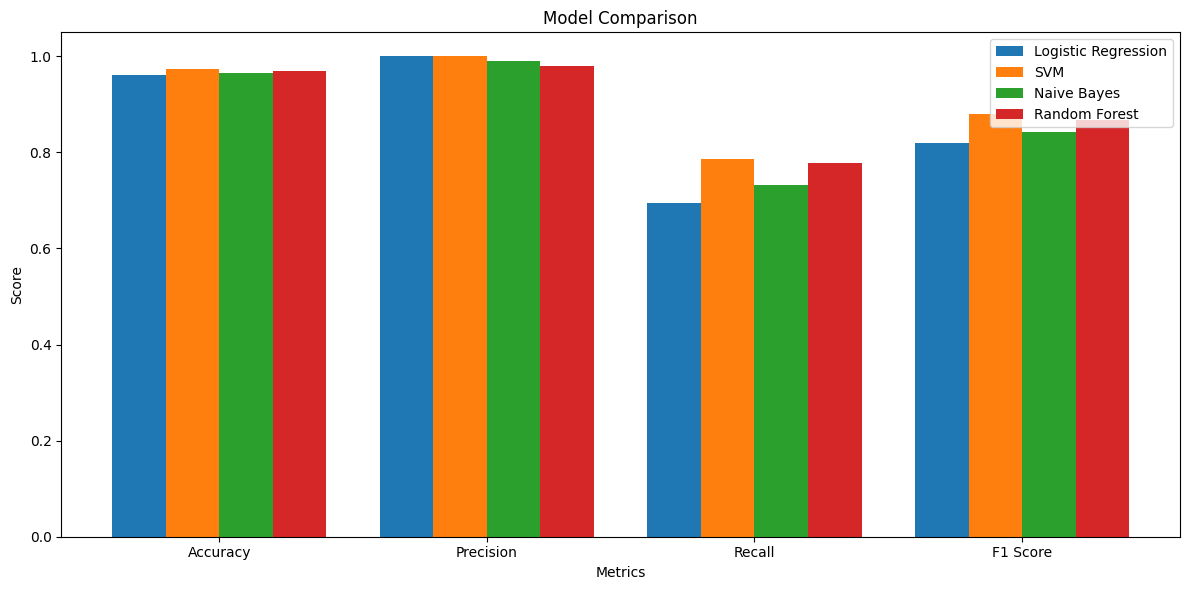

In [12]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

for i, (_, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, row[metrics], width, label=row['Model'])

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend()
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

## 7. Confusion Matrix - Best Model (SVM)

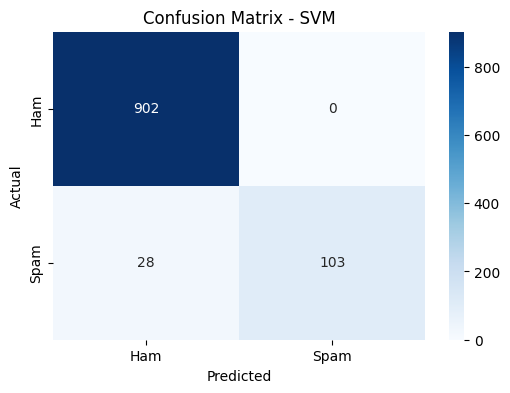

In [13]:
best_model = models['SVM']
y_pred_svm = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

## 8. Saving Best Model

In [14]:
pickle.dump(best_model, open('../model.pkl', 'wb'))
print("Model saved successfully!")

Model saved successfully!
